# High-throughput hyphal image analysis workflow 

In [1]:
# Set the plotting backend for use in jupyter notebook
%matplotlib widget

# Import necessary software packages
from plantcv import plantcv as pcv
from plantcv.parallel import WorkflowInputs

# Set the plantcv functions to "plot" images to the notebook to help visualize what each function does 
pcv.params.debug = "plot" 

About this notebook:

Written by Haley Schuhl for Ben Sikes and his lab working on quantification of blue-stained hyphae in image scans. Testing approaches for segmentation of hyphae from microscrope images.

Updated: 22 September, 2025 - workflow clean up and batch processing compatibility 


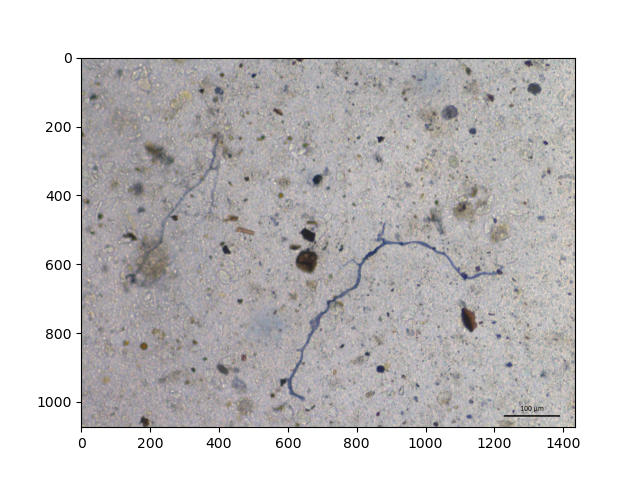

In [16]:
args = WorkflowInputs(images=["./image (23).png"],
                      names="image1",
                      result="plantcv_results.json",
                      debug="plot")

img, path, filename = pcv.readimage(filename=args.image1)


## Segmentation 

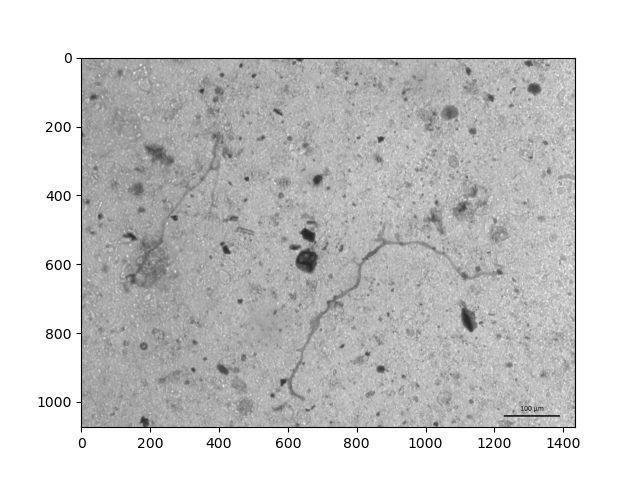

/Users/hschuhl/Documents/GitHub/plantcv/plantcv/plantcv/plot_image.py:33: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


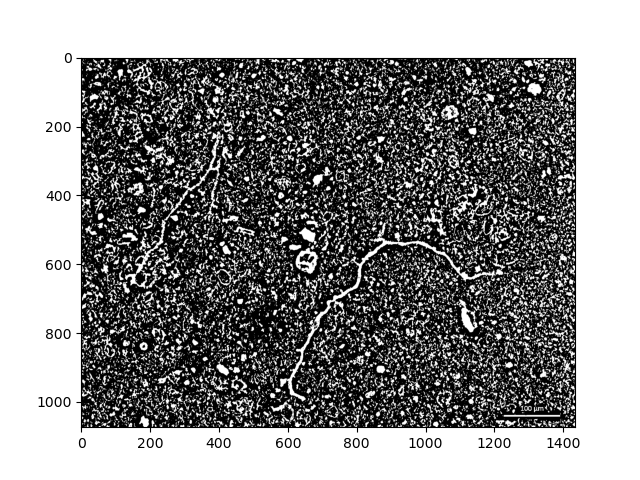

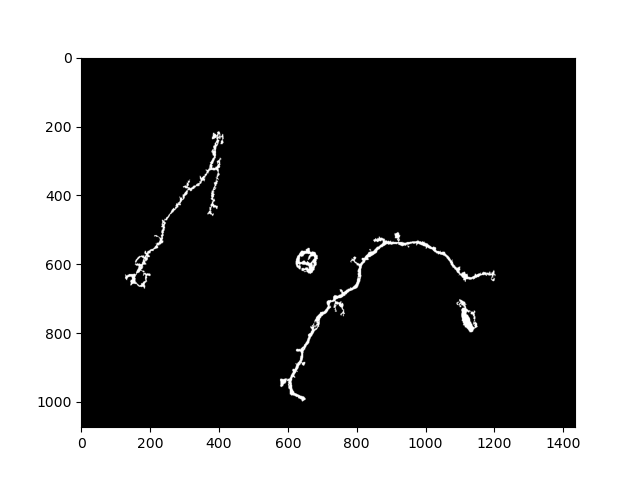

In [17]:
# Use the "value" channel from the HSV colorspace for segmenation
v = pcv.rgb2gray_hsv(rgb_img=img, channel="v")
# Gaussian segmentation to threshold the objects of interest
adaptive_mask = pcv.threshold.gaussian(gray_img=v, ksize=45, offset=7, object_type="dark")
# Remove small objects below the "size" threshold
clean_edges = pcv.fill(bin_img=adaptive_mask, size=1900)

# Mask cleanup and visualization 

Min value = 0.07997490754451358
Max value = 0.6589385474860335
Mean value = 0.3752472158667324


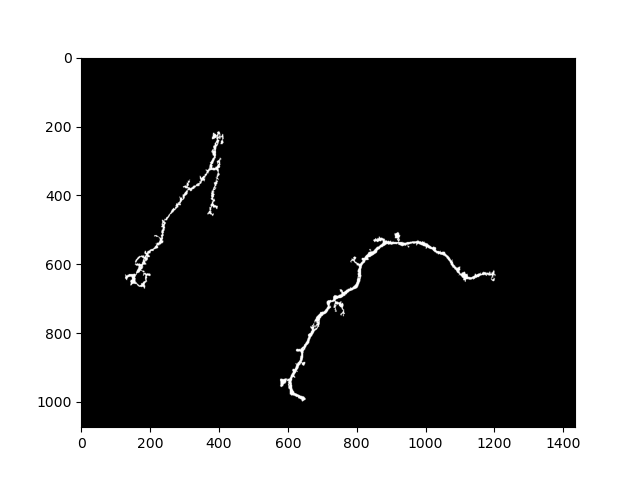

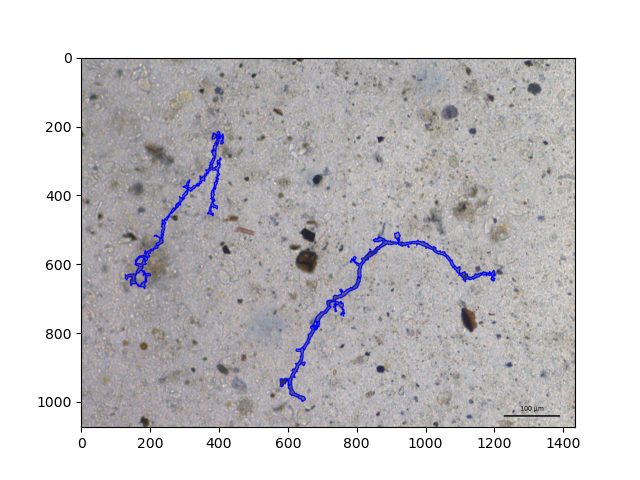

In [18]:
## Use the Value channel and gaussian adaptive threshold to segment hyphae, then clean the mask and visualize result 
import cv2
from plantcv.plantcv._helpers import _cv2_findcontours, _object_composition, _roi_filter, _rgb2hsv

img_copy = img.copy()

if np.count_nonzero(clean_edges) != 0: 
    new_mask = pcv.filters.obj_props(bin_img=clean_edges, cut_side="lower", thresh=.2, regprop="solidity")
    contours, hierarchy = _cv2_findcontours(bin_img=new_mask)
    # If there are more than one contour detected, combine them into one
    marker_contour = _object_composition(contours=contours, hierarchy=hierarchy)
    cv2.drawContours(img_copy, contours, -1, (255), 2, hierarchy=hierarchy)

pcv.plot_image(img_copy)

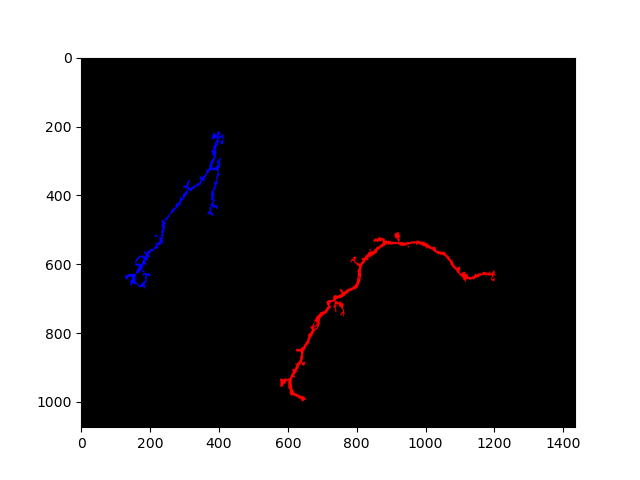

In [19]:
# Create a labeled mask to analyze each object separately 
lbl_mask, num_objects = pcv.create_labels(mask=new_mask)

# Trait extraction 

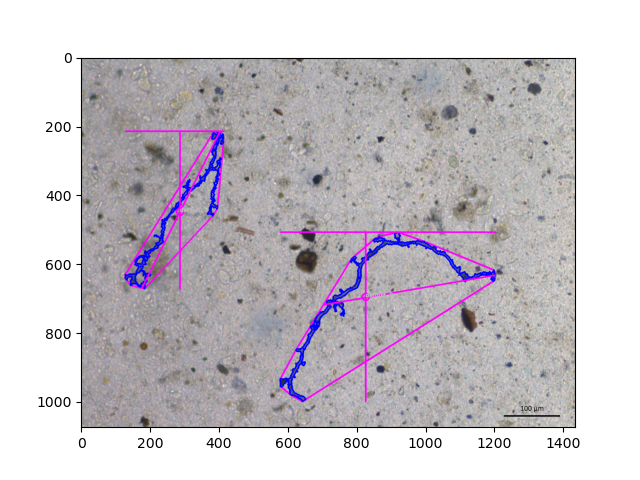

In [21]:
pcv.params.line_thickness = 3
size_img = pcv.analyze.size(img=img, labeled_mask=lbl_mask, n_labels=num_objects)

## Skeletonization trait extration 

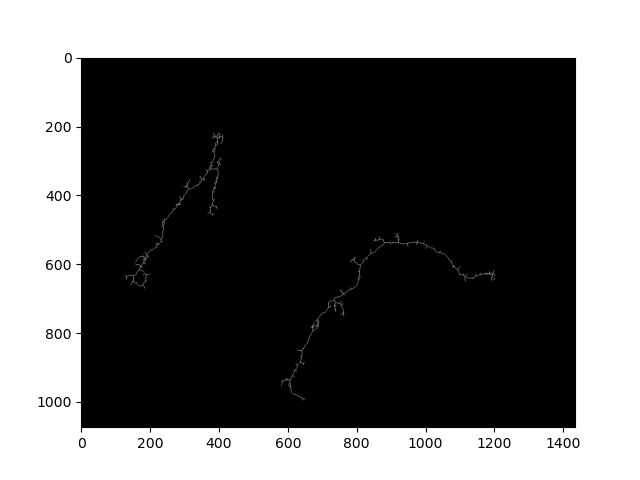

In [22]:
skel = pcv.morphology.skeletonize(mask=new_mask)

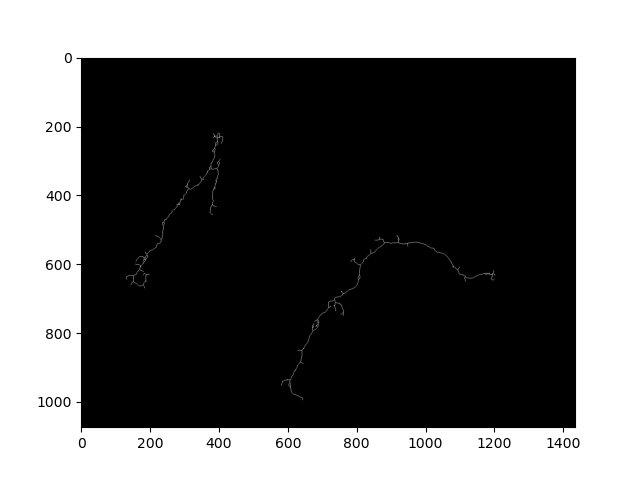

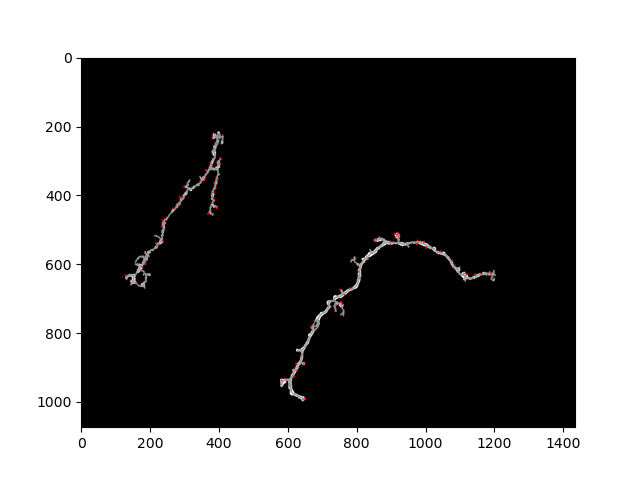

In [26]:
# Prune extra barbs (optional) 
pruned_skel, segmented_img, segment_objects = pcv.morphology.prune(skel_img=skel, mask=new_mask, size=10)


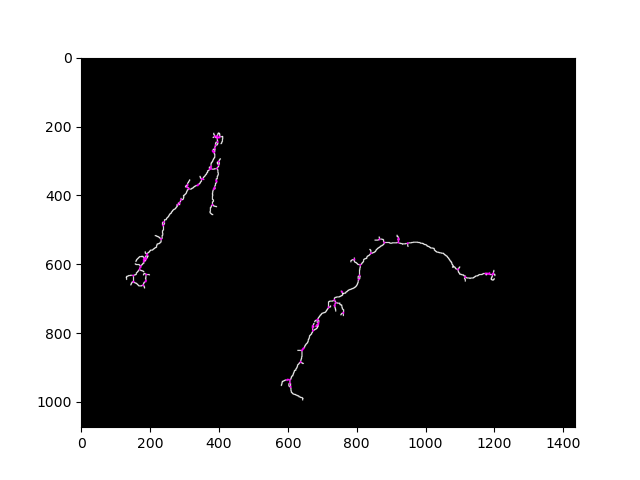

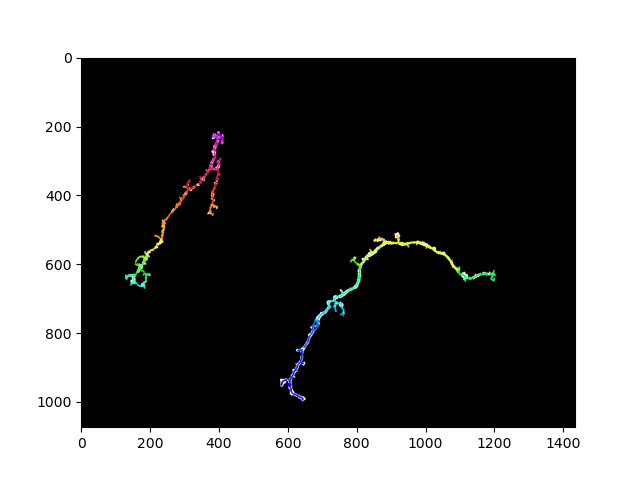

In [27]:
# Break the skeleton into segments
segmented_img, obj = pcv.morphology.segment_skeleton(skel_img=pruned_skel, mask=new_mask)


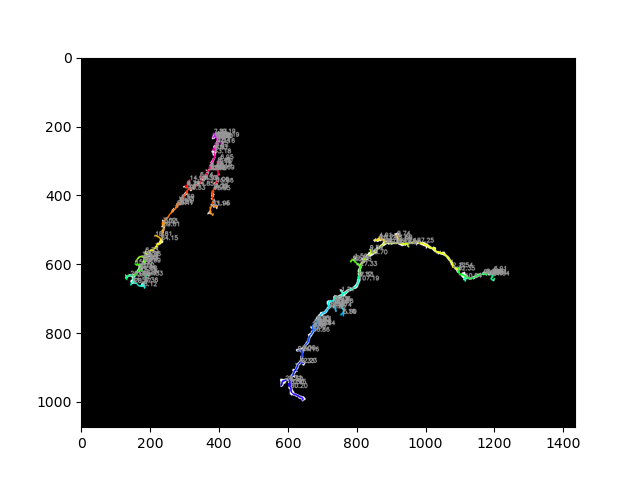

In [28]:
# Extract path length information 
labeled_img = pcv.morphology.segment_path_length(segmented_img=segmented_img, objects=obj)


# Save results out 

In [29]:
pcv.outputs.save_results(filename=args.result) 